# 1. Load the data

In [1]:
# list all the folders in a directory
import os, cv2, numpy as np

import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torchvision import transforms as T
from PIL import Image

ROOT = '/Users/cagatay/Downloads/VidOR'
video_names = os.listdir(os.path.join(ROOT, 'videos'))

def video2frames(mp4_file):
    vidcap = cv2.VideoCapture(mp4_file)
    success,image = vidcap.read()
    frames = []
    while success:
        frames.append(Image.fromarray(image))   
        success,image = vidcap.read()
    return frames # num_frames, [width, height, channels]

def read_segmentation_maps(mp4_file, width, height):
    seg_map_files = os.listdir(os.path.join(ROOT, 'masks', mp4_file))
    seg_map_files = sorted(seg_map_files)
    seg_maps = []
    for seg in seg_map_files:
        if seg.endswith('.png'):
            seg_map = cv2.imread(os.path.join(ROOT, 'masks', mp4_file, seg))
            assert seg_map.shape[0]==width and seg_map.shape[1]==height
            seg_maps.append(seg_map)
    seg_maps = np.array(seg_maps) # num_frames, width, height, channels
    return seg_maps

def build_video(video_name):
    frames = video2frames(os.path.join(ROOT, 'videos', video_name+'.mp4'))
    seg_maps = read_segmentation_maps(video_name, *frames[0].size[::-1])
    if len(seg_maps)!=len(frames):
        return None,None
    else:
        return frames, seg_maps


class VideoDataset(Dataset):
    def __init__(self, video_names, num_videos=10, positive_range=10, transform=None):
        self.frames = []
        self.seg_maps = []
        self.transform = transform
        count = 0
        self.range = positive_range
        for video_name in video_names:
            if count>=num_videos:
                break
            if video_name.endswith('.mp4'):
                frames, seg_maps = build_video(video_name[:-4])
                if frames is not None:
                    print(video_name, len(frames))
                    self.frames.append(frames)
                    self.seg_maps.append(seg_maps)
                    count += 1
                else:
                    print(video_name, 'number of frames and segmentation maps do not match:')
        
    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        frames, seg_maps = self.frames[idx],self.seg_maps[idx]
        len_video = len(frames)
        while True:
            first_idx  = np.random.randint(0, len_video-2*self.range) + self.range
            second_idx = np.random.randint(first_idx-self.range, first_idx+self.range)
            if 0<=second_idx<len_video:
                break
        if self.transform:
            first_frame  = self.transform(frames[first_idx]), self.transform(seg_maps[first_idx])
            second_frame = self.transform(frames[second_idx]),self.transform(seg_maps[second_idx])
        else:
            first_frame  = frames[first_idx], seg_maps[first_idx]
            second_frame = frames[second_idx], seg_maps[second_idx]
        return first_frame, second_frame

transform = T.Compose(
    [
        T.ToTensor(),
        # T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        T.Resize((480,640)),
    ]
)        

video_dataset = VideoDataset(video_names, 5, transform=transform)
data_loader = torch.utils.data.DataLoader(video_dataset, batch_size=1, shuffle=True)

1019_3004044251.mp4 number of frames and segmentation maps do not match:
1111_8115037154.mp4 231
1160_8623061698.mp4 180
1160_5942411333.mp4 451
1102_12754064355.mp4 156
0054_2612939953.mp4 371


# 2. Plotting

### 2.1. Plot two random frames from a video

0 torch.Size([1, 3, 480, 640]) torch.Size([1, 3, 480, 640])


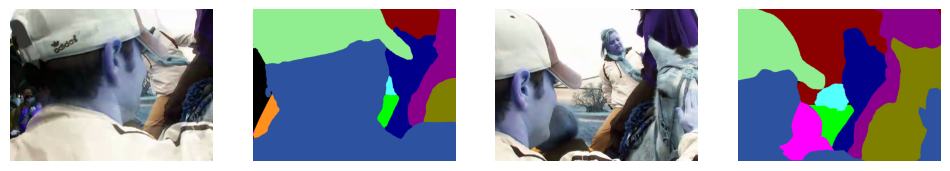

<Figure size 640x480 with 0 Axes>

In [2]:
# plot some samples
N = 1
fig,ax = plt.subplots(N,4,figsize=(12,3*N), squeeze=False)
for i, (first_frames, second_frames) in enumerate(data_loader):
    print(i, first_frames[0].shape, second_frames[0].shape)
    ax[i][0].imshow(first_frames[0][0].permute(1,2,0))
    ax[i][1].imshow(first_frames[1][0].permute(1,2,0))
    ax[i][2].imshow(second_frames[0][0].permute(1,2,0))
    ax[i][3].imshow(second_frames[1][0].permute(1,2,0))
    for j in range(4):
        ax[i,j].axis('off')
    plt.show()
    if i>=N-1:
        break
plt.tight_layout()

### 2.2. Plot all segmentation maps for the above frames

torch.Size([480, 640, 3]) torch.Size([480, 640, 3]) torch.Size([480, 640, 3]) torch.Size([480, 640, 3])
torch.Size([11, 3])


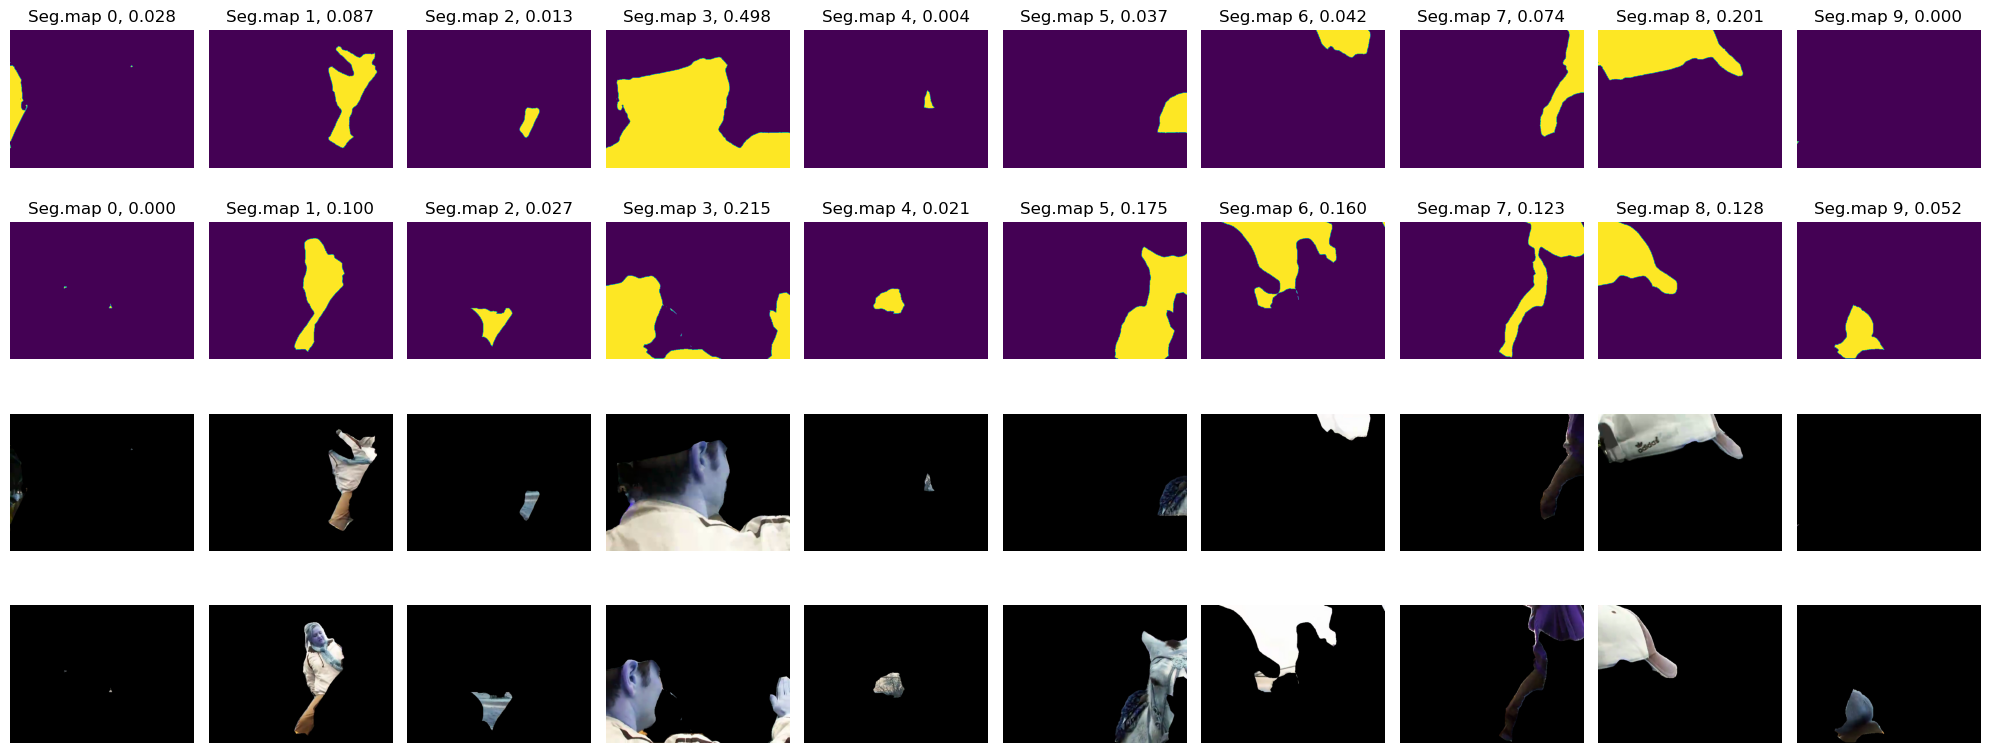

In [3]:
data_point_id = 0
img1,img2 = first_frames[0][data_point_id].permute(1,2,0), second_frames[0][data_point_id].permute(1,2,0)
m1,m2     = first_frames[1][data_point_id].permute(1,2,0), second_frames[1][data_point_id].permute(1,2,0)
print(img1.shape, img2.shape, m1.shape, m2.shape)

# Get unique colors (unique rows of RGB values)
unique_colors = torch.cat([m1.reshape(-1,3),m2.reshape(-1,3)]).unique(dim=0)
print(unique_colors.shape)

# Create a binary mask for each unique color
masks1,masks2 = [],[]
for color in unique_colors:
    mask1 = (m1 == color).all(dim=-1).float()
    masks1.append(mask1)
    mask2 = (m2 == color).all(dim=-1).float()
    masks2.append(mask2)

# Plot the masks
num_plot_masks = min(10,len(masks1))
fig,ax = plt.subplots(4, num_plot_masks, figsize=(2*num_plot_masks,8))
for i,[masks,img] in enumerate(zip([masks1,masks2],[img1,img2])):
    for j, mask in enumerate(masks):
        ax[i,j].imshow(mask)
        ax[i+2,j].imshow(mask[:,:,None]*img)
        ax[i,j].set_title(r"Seg.map {:d}, {:.3f}".format(j,mask.mean()), fontsize=12)
        ax[i,j].axis('off')
        ax[i+2,j].axis('off')
        if j>=num_plot_masks-1:
            break
plt.tight_layout()

# 3. DINO features computation

Using cache found in /Users/cagatay/.cache/torch/hub/facebookresearch_dino_main


0 torch.Size([1, 3, 480, 640]) torch.Size([1, 3, 480, 640])
0 torch.Size([1, 3, 480, 640]) torch.Size([1, 3, 480, 640])


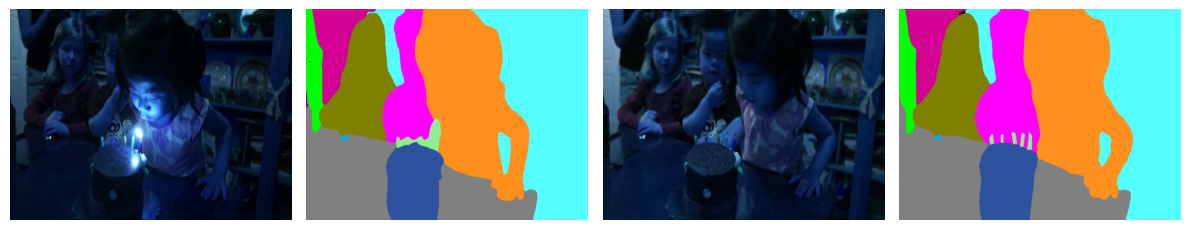

7
tensor(0.8199)
tensor(0.9309)
tensor(0.9562)
tensor(0.9228)
tensor(0.6659)
tensor(0.9410)
tensor(0.9549)


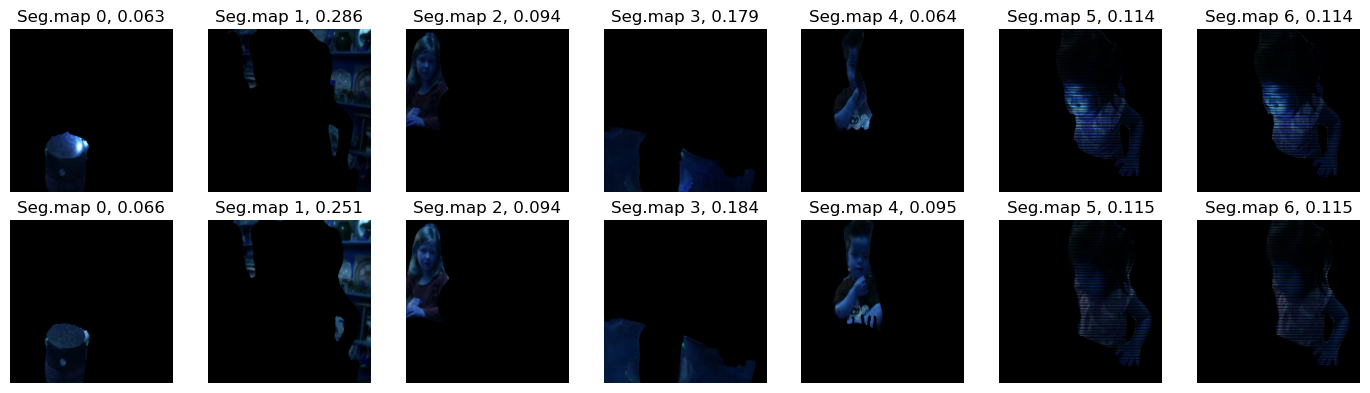

In [65]:
vits8 = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')

dino_transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# fig,ax = plt.subplots(1,4,figsize=(12,3), squeeze=False)
for i, (first_frames, second_frames) in enumerate(data_loader):
    if i>0:
        break
    print(i, first_frames[0].shape, second_frames[0].shape)
    
    img1,img2 = first_frames[0][0].permute(1,2,0), second_frames[0][0].permute(1,2,0)
    m1,m2     = first_frames[1][0].permute(1,2,0), second_frames[1][0].permute(1,2,0)

    # Get unique colors (unique rows of RGB values)
    unique_colors = torch.cat([m1.reshape(-1,3),m2.reshape(-1,3)]).unique(dim=0)

    # Create a binary mask for each unique color
    masks1,masks2 = [],[]
    for color in unique_colors:
        mask1 = (m1 == color).all(dim=-1).float()
        mask2 = (m2 == color).all(dim=-1).float()
        mask1 = torch.stack([mask1]*3, dim=-1)
        mask2 = torch.stack([mask2]*3, dim=-1)
        if mask1.mean()>0.05 and mask2.mean()>0.05:
            masks1.append(mask1)
            masks2.append(mask2)

    # plot the sample
    fig,ax = plt.subplots(1,4,figsize=(12,3), squeeze=False)
    print(i, first_frames[0].shape, second_frames[0].shape)
    ax[i][0].imshow(first_frames[0][0].permute(1,2,0))
    ax[i][1].imshow(first_frames[1][0].permute(1,2,0))
    ax[i][2].imshow(second_frames[0][0].permute(1,2,0))
    ax[i][3].imshow(second_frames[1][0].permute(1,2,0))
    for j in range(4):
        ax[i,j].axis('off')
    plt.tight_layout()
    plt.show()

    num_plot_masks = min(10,len(masks1))
    print(num_plot_masks)
    fig,ax = plt.subplots(2, num_plot_masks, figsize=(2*num_plot_masks,4))
    for k in range(len(masks1)):
        mask1, mask2 = masks1[k], masks2[k]
        final_img1 = dino_transform((img1*mask1).permute(2,0,1)).permute(1,2,0)
        ax[0,k].imshow(final_img1)
        ax[0,k].set_title(r"Seg.map {:d}, {:.3f}".format(k,mask1.mean()), fontsize=12)
        ax[0,k].axis('off')
        final_img2 = dino_transform((img2*mask2).permute(2,0,1)).permute(1,2,0)
        ax[1,k].imshow(final_img2)
        ax[1,k].set_title(r"Seg.map {:d}, {:.3f}".format(k,mask2.mean()), fontsize=12)
        ax[1,k].axis('off')

        with torch.no_grad():
            images = torch.stack([final_img1, final_img2]).permute(0,3,1,2)
            activations = vits8(images)
            print((activations[0]*activations[1]).sum() / (activations[0].norm()*activations[1].norm()))

        if k>=num_plot_masks-1:
            break
    plt.tight_layout()
    plt.show()

